# Urbancity Capstone : Machine Learning Models

**Instructor:** Abishek Ganesh

**Your Name:** Kalpana  
**Your Role:** Data Scientist  



### How to Verify Your Work
- **Assert Tests**: I have provided `assert` statements to help you check your work. Your code should pass all of them.
- **Example Outputs**: Each section shows expected outputs. Compare yours to make sure you're on track.
- **Written Reflections**: Answer all reflection questions - they help me understand your thinking.

---

## Setup: Import Libraries

Run this cell first to import all the libraries you'll need.

In [1]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression
from sklearn.linear_model import LinearRegression

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part 1: Problem Definition & Data Loading

**The Problem:** Before training any model, we need to load and understand our data.

The dataset is `urbanpulse_311_complaints.csv` — 434,722 real NYC 311 service complaints with complaint type, status, agency, borough, dates, and free-text descriptions.

**Your Goal:** Load the data and verify its structure.

### Task: Load the Customer Data

**Your Task:** Create a function that loads the customer data and returns a DataFrame.

### Example Verification
```python
df = load_customer_data('urbanpulse_311_complaints.csv')
print(df.shape)  # Should print (434722, 11)
```

In [2]:
def load_customer_data(filepath):
    """
    Load customer data from a CSV file.
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: The loaded data
    """
    # Your code here
    return pd.read_csv(filepath)

In [3]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Load the data
df = load_customer_data('urbanpulse_311_complaints.csv')

# Basic Verification
assert df is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df, pd.DataFrame), "Function should return a pandas DataFrame"
assert df.shape == (434722, 11), f"Expected shape (434722, 11), got {df.shape}"
assert 'complaint_type' in df.columns, "Missing classification target 'complaint_type'"
print("[PASS] Part 1 Tests Passed!")
print(f"\nDataset loaded: {df.shape[0]:,} customers, {df.shape[1]} columns")

[PASS] Part 1 Tests Passed!

Dataset loaded: 434,722 customers, 11 columns


In [4]:
# Take a first look at the data
df.head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
5,68173650,2026-03-01T13:18:50.000,2026-03-01T13:41:16.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,ONLINE,Closed
6,67996182,2026-02-14T04:34:09.000,2026-02-14T07:30:31.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
7,67989111,2026-02-13T13:14:39.000,2026-02-15T21:30:43.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,This complaint is a duplicate of a building-wi...,QUEENS,ONLINE,Closed
8,68284021,2026-03-10T08:15:03.000,2026-03-11T14:26:55.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
9,67918125,2026-02-09T11:41:22.000,NaN,DOHMH,Department of Health and Mental Hygiene,Non-Residential Heat,Inadequate or No Heat,The Department of Health and Mental Hygiene ha...,BRONX,ONLINE,In Progress


In [5]:
# Check the data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 434722 entries, 0 to 434721
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   unique_key              434722 non-null  int64
 1   created_date            434722 non-null  str  
 2   closed_date             384642 non-null  str  
 3   agency                  434722 non-null  str  
 4   agency_name             434722 non-null  str  
 5   complaint_type          434722 non-null  str  
 6   descriptor              431047 non-null  str  
 7   resolution_description  434722 non-null  str  
 8   borough                 434722 non-null  str  
 9   open_data_channel_type  434722 non-null  str  
 10  status                  434722 non-null  str  
dtypes: int64(1), str(10)
memory usage: 238.3 MB


In [6]:
# Check the churn distribution (class imbalance?)
print("complaint_type")
print(df['complaint_type'].value_counts(normalize=True))

complaint_type
complaint_type
Illegal Parking                   0.152187
HEAT/HOT WATER                    0.148053
Noise - Residential               0.089554
Snow or Ice                       0.063151
Blocked Driveway                  0.057324
                                    ...   
Illegal Animal Sold               0.000005
Found Property                    0.000002
Building Marshal's Office         0.000002
Institution Disposal Complaint    0.000002
Dept of Investigations            0.000002
Name: proportion, Length: 151, dtype: float64


---

## Exploratory Data Analysis (EDA)

Before building models, we explore the data to understand distributions, patterns, and potential issues like class imbalance or missing values.

In [7]:
# 1. Missing Values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0].sort_values(ascending=False))
print(f'\nTotal missing: {missing.sum():,} out of {df.size:,} values ')
print(f'({missing.sum()/df.size*100:.2f}%)')


Missing values per column:
closed_date    50080
descriptor      3675
dtype: int64

Total missing: 53,755 out of 4,781,942 values 
(1.12%)


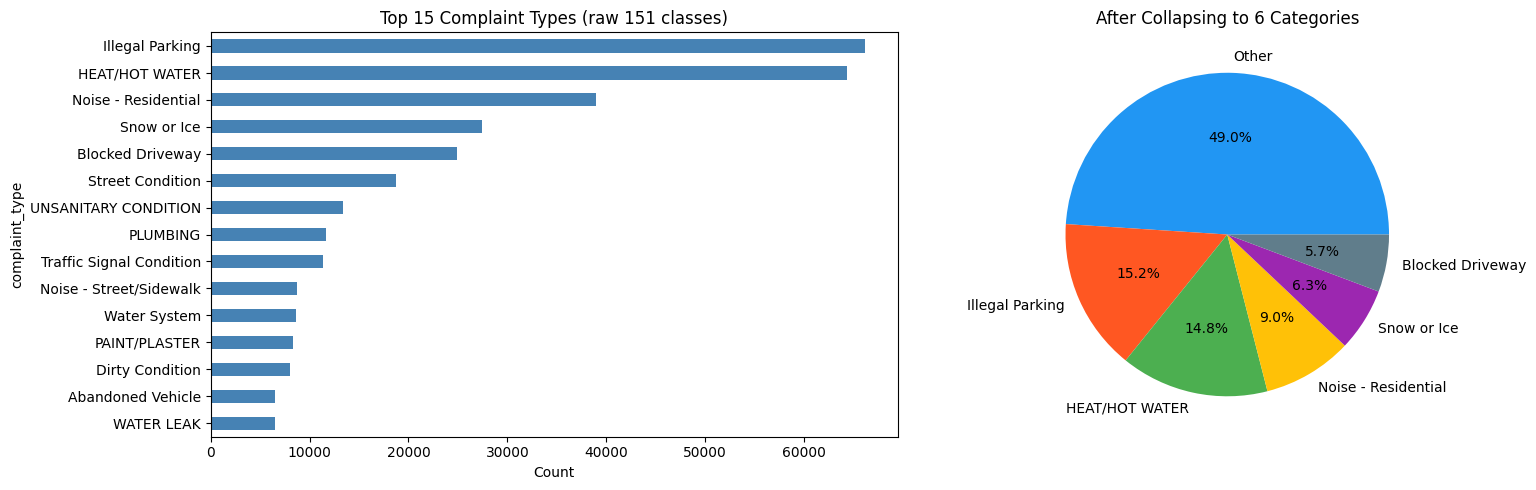


Top 5 categories as % of total:
complaint_type
Other                  49.0
Illegal Parking        15.2
HEAT/HOT WATER         14.8
Noise - Residential     9.0
Snow or Ice             6.3
Blocked Driveway        5.7


In [8]:
# 2. Target Variable — Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 raw complaint types
df['complaint_type'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Complaint Types (raw 151 classes)')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# After collapsing to 6 categories
cat_counts = df['complaint_type'].apply(
    lambda x: x if x in ['Illegal Parking','HEAT/HOT WATER','Noise - Residential',
                          'Snow or Ice','Blocked Driveway'] else 'Other'
)
cat_counts.value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
    colors=['#2196F3','#FF5722','#4CAF50','#FFC107','#9C27B0','#607D8B'])
axes[1].set_title('After Collapsing to 6 Categories')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

print('\nTop 5 categories as % of total:')
print(cat_counts.value_counts(normalize=True).mul(100).round(1).to_string())


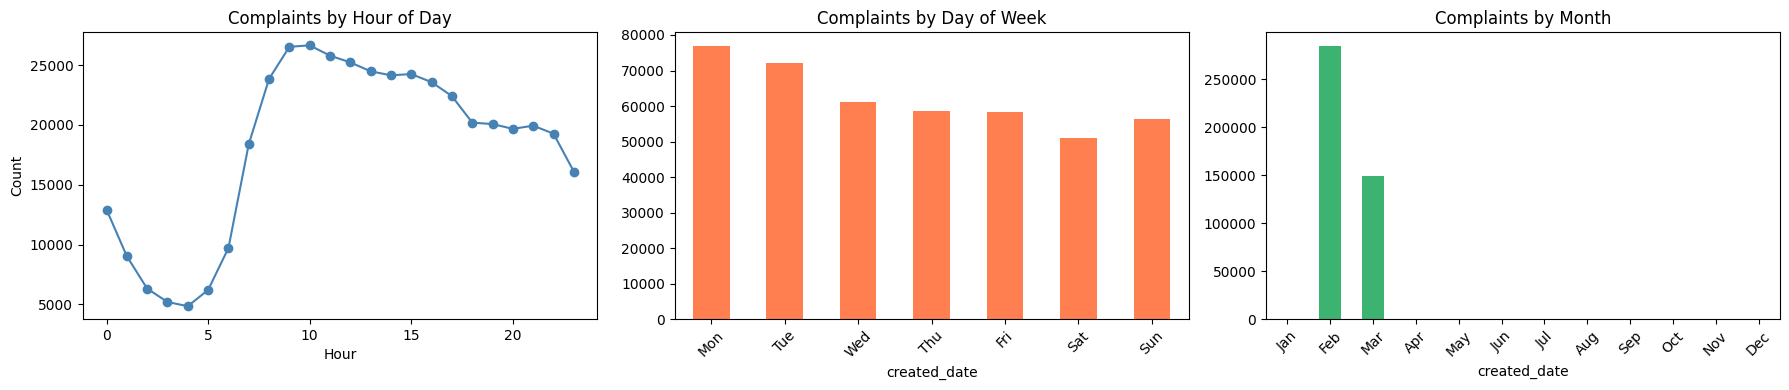

In [9]:
# 3. Temporal Patterns
df['created_date'] = pd.to_datetime(df['created_date'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# By hour of day
df['created_date'].dt.hour.value_counts().sort_index().plot(
    ax=axes[0], color='steelblue', marker='o')
axes[0].set_title('Complaints by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# By day of week — map numbers to names instead of replacing index
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
day_counts = (df['created_date'].dt.dayofweek
              .map(day_map)
              .value_counts()
              .reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))
day_counts.plot(ax=axes[1], kind='bar', color='coral')
axes[1].set_title('Complaints by Day of Week')
axes[1].tick_params(axis='x', rotation=45)

# By month — map numbers to names instead of replacing index
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_counts = (df['created_date'].dt.month
                .map(month_map)
                .value_counts()
                .reindex(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec']))
month_counts.plot(ax=axes[2], kind='bar', color='mediumseagreen')
axes[2].set_title('Complaints by Month')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


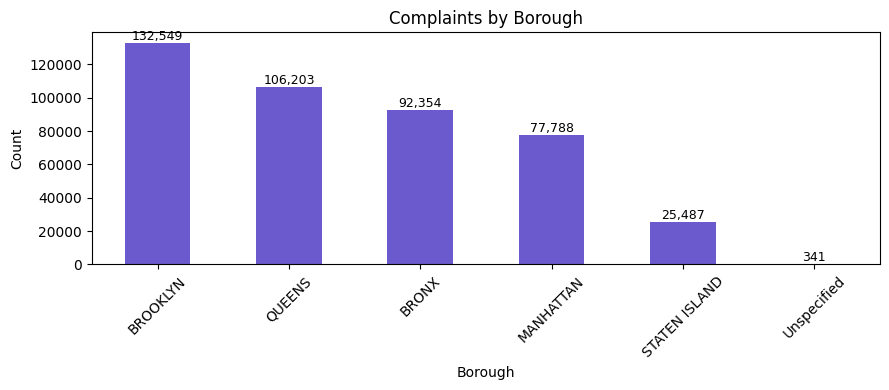

In [10]:
# 4. Geographic Distribution — Borough
fig, ax = plt.subplots(figsize=(9, 4))
df['borough'].value_counts().plot(kind='bar', ax=ax, color='slateblue')
ax.set_title('Complaints by Borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


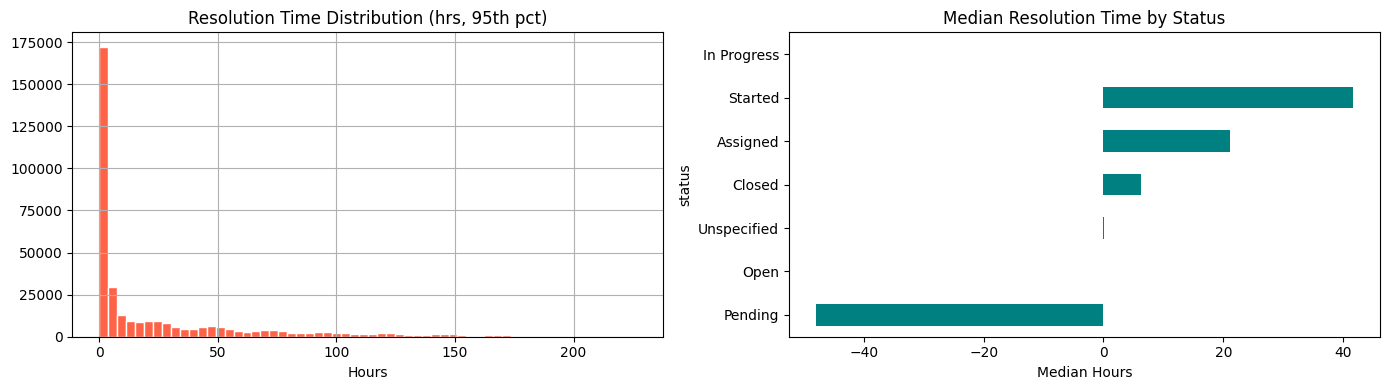

Resolution time stats (hours):
count    384642.0
mean         48.6
std         106.0
min        -240.0
25%           1.0
50%           5.9
75%          49.6
max        7274.1
Name: resolution_hours, dtype: float64


In [11]:
# 5. Resolution Time Distribution
df['closed_date'] = pd.to_datetime(df['closed_date'])
df['resolution_hours'] = (
    df['closed_date'] - df['created_date']
).dt.total_seconds() / 3600

rt = df['resolution_hours'].dropna()
rt = rt[(rt >= 0) & (rt <= rt.quantile(0.95))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rt.hist(bins=60, ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Resolution Time Distribution (hrs, 95th pct)')
axes[0].set_xlabel('Hours')

df.groupby('status')['resolution_hours'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Median Resolution Time by Status')
axes[1].set_xlabel('Median Hours')
plt.tight_layout()
plt.show()

print('Resolution time stats (hours):')
print(df['resolution_hours'].describe().round(1))


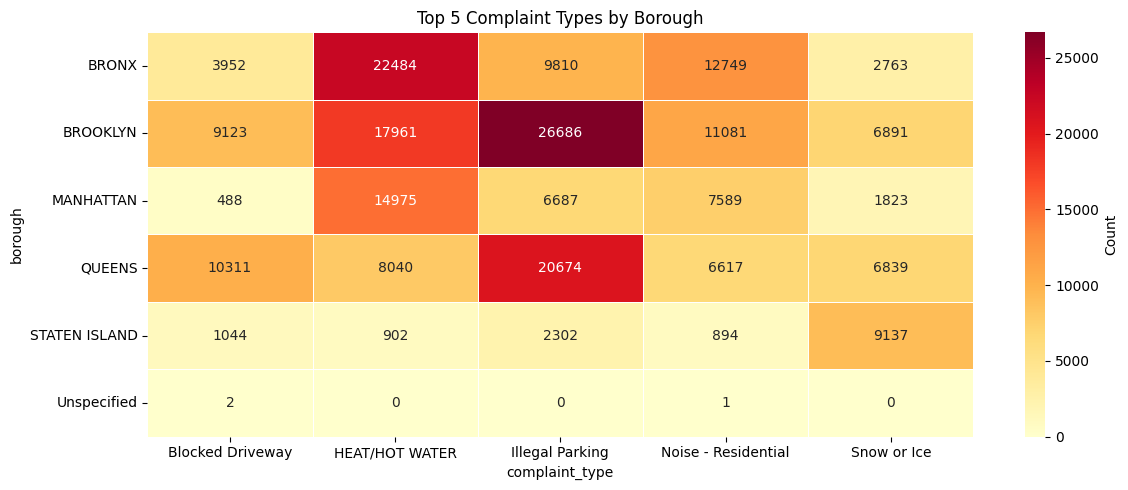

In [12]:
# 6. Complaint Type vs Borough Heatmap
top_5 = ['Illegal Parking','HEAT/HOT WATER','Noise - Residential',
         'Snow or Ice','Blocked Driveway']
heat_df = df[df['complaint_type'].isin(top_5)].copy()
pivot = heat_df.groupby(['borough','complaint_type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Top 5 Complaint Types by Borough')
plt.tight_layout()
plt.show()


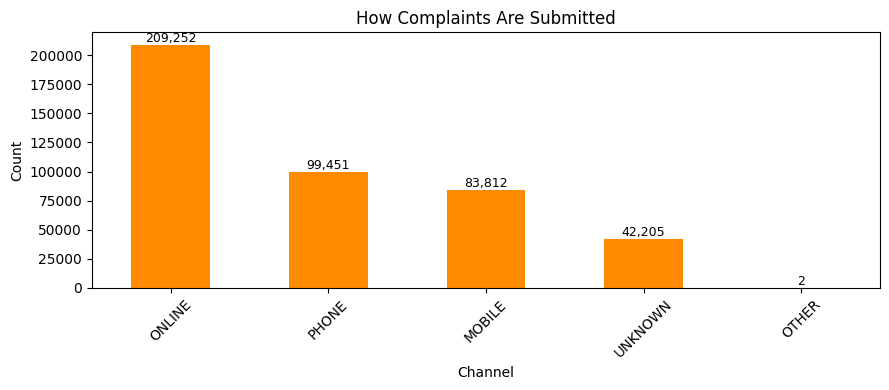

In [13]:
# 7. Submission Channel
fig, ax = plt.subplots(figsize=(9, 4))
df['open_data_channel_type'].value_counts().plot(
    kind='bar', ax=ax, color='darkorange')
ax.set_title('How Complaints Are Submitted')
ax.set_xlabel('Channel')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


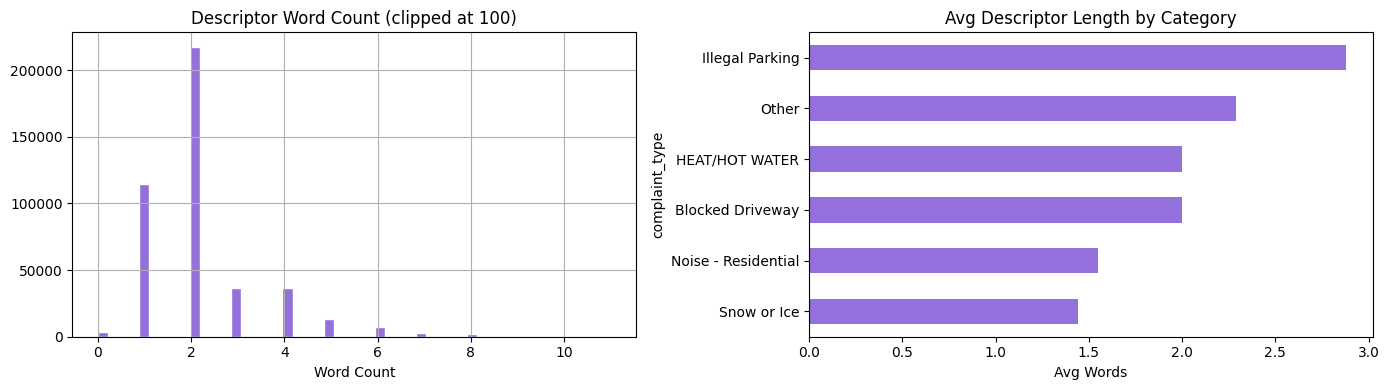

Descriptor word count stats:
count    434722.0
mean          2.2
std           1.3
min           0.0
25%           1.0
50%           2.0
75%           2.0
max          11.0
Name: text_length, dtype: float64


In [14]:
# 8. Descriptor Text Length Analysis
df['text_length'] = df['descriptor'].fillna('').apply(lambda x: len(x.split()))

top_5 = ['Illegal Parking','HEAT/HOT WATER','Noise - Residential',
         'Snow or Ice','Blocked Driveway']
cat_label = df['complaint_type'].apply(lambda x: x if x in top_5 else 'Other')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['text_length'].clip(upper=100).hist(bins=50, ax=axes[0], color='mediumpurple',
                                        edgecolor='white')
axes[0].set_title('Descriptor Word Count (clipped at 100)')
axes[0].set_xlabel('Word Count')

df.groupby(cat_label)['text_length'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Avg Descriptor Length by Category')
axes[1].set_xlabel('Avg Words')

plt.tight_layout()
plt.show()

print('Descriptor word count stats:')
print(df['text_length'].describe().round(1))


---

## Part 2: Data Preparation

**The Problem:** Before training any models, we need to:
1. Handle missing values
2. Encode categorical variables
3. Scale numeric features (important for Logistic Regression)
4. Split our data into training and test sets

**Note:** You can reference your Unit 2 capstone code for handling missing values, encoding, and scaling - the techniques are the same!

### Task 2a: Prepare Features

Create a function that:
 Steps:
    1. Drop non-predictive columns (unique_key, resolution_description, agency_name, descriptor)

    2. Engineer time-based features from created_date and closed_date

    3. Fill missing values

    4. Encode status ordinally

    5. One-hot encode borough, open_data_channel_type, and agency
    
    6. Scale numeric features using StandardScaler

In [15]:
import re
from sklearn.preprocessing import StandardScaler

def preprocess_311_text(text: str) -> str:
    """
    Clean and normalize 311 complaint text for classification.
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs and emails BEFORE punctuation stripping
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    # 3. Remove ordinal numbers whole (5th, 42nd, 1st, 3rd, etc.)
    text = re.sub(r'\b\d+(?:st|nd|rd|th)\b', '', text)

    # 4. Strip non-ASCII characters (handles Chinese, Spanish, etc.)
    text = text.encode('ascii', errors='ignore').decode('ascii')

    # 5. Remove all punctuation except apostrophes
    text = re.sub(r"[^\w\s']", ' ', text)

    # 6. Remove remaining digit sequences
    text = re.sub(r'\d+', '', text)

    # 7. Collapse repeated characters ("sooooo" -> "soo")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 8. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Truncate to 100 words
    words = text.split()
    if len(words) > 100:
        text = ' '.join(words[:100])

    return text


def prepare_features(df):
    """
    Prepare features for machine learning on the urbanpulse 311 complaints dataset.

    Steps:
    1. Drop non-predictive columns (unique_key, resolution_description, agency_name)
    2. Engineer time-based features from created_date and closed_date
    3. Fill missing values
    4. Encode status ordinally
    5. One-hot encode borough, open_data_channel_type, and agency
    6. Scale numeric features using StandardScaler
    7. Clean descriptor text using preprocess_311_text

    Args:
        df (pd.DataFrame): The raw DataFrame

    Returns:
        pd.DataFrame: The prepared DataFrame with all numeric columns (scaled)
                      and a cleaned descriptor column.
    """
    df_prep = df.copy()

    # Step 1: Drop non-predictive / high-cardinality columns
    df_prep = df_prep.drop(
        columns=['unique_key', 'resolution_description', 'agency_name'],
        errors='ignore'
    )

    # Step 2: Engineer time-based features from dates
    df_prep['created_date'] = pd.to_datetime(df_prep['created_date'])
    df_prep['closed_date']  = pd.to_datetime(df_prep['closed_date'])

    df_prep['created_hour']      = df_prep['created_date'].dt.hour
    df_prep['created_dayofweek'] = df_prep['created_date'].dt.dayofweek
    df_prep['created_month']     = df_prep['created_date'].dt.month
    df_prep['resolution_hours']  = (
        df_prep['closed_date'] - df_prep['created_date']
    ).dt.total_seconds() / 3600

    df_prep = df_prep.drop(columns=['created_date', 'closed_date'])

    # Step 3: Fill missing values
    df_prep['resolution_hours'] = df_prep['resolution_hours'].fillna(
        df_prep['resolution_hours'].median()
    )

    # Step 4: Encode status ordinally
    status_mapping = {
        'Open': 0, 'Assigned': 1, 'Started': 2,
        'In Progress': 3, 'Pending': 4, 'Closed': 5, 'Unspecified': 0
    }
    df_prep['status'] = df_prep['status'].map(status_mapping).fillna(0).astype(int)

    # Step 5: One-hot encode categorical columns
    df_prep = pd.get_dummies(
        df_prep, columns=['borough', 'open_data_channel_type', 'agency'], dtype=int
    )

    # Step 6: Scale numeric features
    scaler = StandardScaler()
    exclude_cols = {'status', 'complaint_type', 'descriptor'}
    onehot_prefixes = ('borough_', 'open_data_channel_type_', 'agency_')
    numeric_cols = [
        col for col in df_prep.select_dtypes(include=['int64', 'float64']).columns
        if col not in exclude_cols and not col.startswith(onehot_prefixes)
    ]
    df_prep[numeric_cols] = scaler.fit_transform(df_prep[numeric_cols])

    df_prep = df_prep.fillna(0)

    # Step 7: Clean descriptor text
    df_prep['descriptor'] = df_prep['descriptor'].fillna('').apply(preprocess_311_text)

    return df_prep

### Verification: `prepare_features()` for 311 Dataset

| Check | What it verifies |
|-------|------------------|
| **Dropped columns** | `unique_key`, `resolution_description`, `agency_name`, `created_date`, `closed_date` are removed |
| **No missing values** | All nulls filled (e.g., `resolution_hours` median-filled) |
| **Status encoding** | Ordinal encoded 0–5 (Open → Closed) |
| **One-hot encoding** | `borough` (6 cols), `open_data_channel_type` (5 cols), `agency` (14 cols) — originals removed |
| **Engineered features** | `created_hour`, `created_dayofweek`, `created_month`, `resolution_hours` exist |
| **Summary print** | Shape, missing value count, and column list |

In [16]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# ============================================================

df_prepared = prepare_features(df)

# Basic Verification
assert df_prepared is not None, "Function returned None"
assert 'unique_key' not in df_prepared.columns, "unique_key should be dropped"
assert 'resolution_description' not in df_prepared.columns, "resolution_description should be dropped"
assert 'agency_name' not in df_prepared.columns, "agency_name should be dropped"
assert 'created_date' not in df_prepared.columns, "created_date should be dropped"
assert 'closed_date' not in df_prepared.columns, "closed_date should be dropped"
assert df_prepared.isnull().sum().sum() == 0, f"Still have {df_prepared.isnull().sum().sum()} missing values!"
assert df_prepared['status'].dtype in ['int64', 'int32', 'float64'], "status should be numeric"
assert 'complaint_type' in df_prepared.columns, "Missing target column complaint_type"
assert 'created_hour' in df_prepared.columns, "Missing feature created_hour"
assert 'created_dayofweek' in df_prepared.columns, "Missing feature created_dayofweek"
assert 'created_month' in df_prepared.columns, "Missing feature created_month"
assert 'resolution_hours' in df_prepared.columns, "Missing feature resolution_hours"
borough_cols = [col for col in df_prepared.columns if col.startswith('borough_')]
assert len(borough_cols) > 0, "borough should be one-hot encoded"
channel_cols = [col for col in df_prepared.columns if col.startswith('open_data_channel_type_')]
assert len(channel_cols) > 0, "open_data_channel_type should be one-hot encoded"
agency_cols = [col for col in df_prepared.columns if col.startswith('agency_')]
assert len(agency_cols) > 0, "agency should be one-hot encoded"
print("[PASS] Part 2a Preparation Tests Passed!")
print(f"\nPrepared DataFrame: {df_prepared.shape[0]} rows, {df_prepared.shape[1]} columns")
print(f"Missing values: {df_prepared.isnull().sum().sum()}")
print(f"Columns: {list(df_prepared.columns)}")


[PASS] Part 2a Preparation Tests Passed!

Prepared DataFrame: 434722 rows, 33 columns
Missing values: 0
Columns: ['complaint_type', 'descriptor', 'status', 'resolution_hours', 'text_length', 'created_hour', 'created_dayofweek', 'created_month', 'borough_BRONX', 'borough_BROOKLYN', 'borough_MANHATTAN', 'borough_QUEENS', 'borough_STATEN ISLAND', 'borough_Unspecified', 'open_data_channel_type_MOBILE', 'open_data_channel_type_ONLINE', 'open_data_channel_type_OTHER', 'open_data_channel_type_PHONE', 'open_data_channel_type_UNKNOWN', 'agency_DCWP', 'agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD', 'agency_OOS', 'agency_OTI', 'agency_TLC']


---

## Part 2b: Complaint Category Mapping

**Your Task:** Map the 151 complaint types down to the top 5 + an `"Other"` bucket (6 classes total). This makes classification practical for city operations teams.

In [17]:
def create_complaint_categories(df: pd.DataFrame) -> pd.DataFrame:
    """
    Map complaint types to the top 5 categories + "Other" (6 classes total).

    The top 5 categories are:
    - Illegal Parking
    - HEAT/HOT WATER
    - Noise - Residential
    - Snow or Ice
    - Blocked Driveway

    Everything else maps to "Other". This gives you 6 classes total —
    a much more manageable classification problem than 186 categories.
    """
    top_5 = {
        "Illegal Parking",
        "HEAT/HOT WATER",
        "Noise - Residential",
        "Snow or Ice",
        "Blocked Driveway",
    }
    
    df = df.copy()
    df["complaint_type"] = df["complaint_type"].where(
        df["complaint_type"].isin(top_5), other="Other"
    )
    return df


In [18]:
df_categorized = create_complaint_categories(df_prepared)

# Basic Verification
assert df_categorized is not None, "Function returned None"
assert 'complaint_type' in df_categorized.columns, "Missing complaint_type column"
assert df_categorized['complaint_type'].nunique() == 6, \
    f"Expected 6 categories, got {df_categorized['complaint_type'].nunique()}"
assert 'descriptor' in df_categorized.columns, \
    "Missing descriptor column — check prepare_features drops only unique_key, resolution_description, agency_name"

print("[PASS] Part 2b Categorization Tests Passed!")
print(f"  Shape         : {df_categorized.shape}")
print(f"  Has descriptor: {'descriptor' in df_categorized.columns}")
print(f"\nComplaint type distribution:")
print(df_categorized['complaint_type'].value_counts(normalize=True).mul(100).round(1).to_string())


[PASS] Part 2b Categorization Tests Passed!
  Shape         : (434722, 33)
  Has descriptor: True

Complaint type distribution:
complaint_type
Other                  49.0
Illegal Parking        15.2
HEAT/HOT WATER         14.8
Noise - Residential     9.0
Snow or Ice             6.3
Blocked Driveway        5.7


In [19]:
# Test the function
test_cases = [
    "This is a test! Visit http://example.com for more info. Contact me at user@example.com.",
    "Pothole on 5th Ave near 42nd St. Please fix!",
    "So many cars parked illegally on my street. It's a nightmare! Sooooo annoying!!!",
    "噪音投诉！晚上音乐太吵了！",
    "Heat not working since 12/01/2023. Please send someone! My address is 123 Main St, zip 90210."
]
for i, text in enumerate(test_cases):
    processed = preprocess_311_text(text)
    print(f"Test Case {i+1}:\nOriginal:  {text}\nProcessed: {processed}\n{'-'*50}")

# Apply to descriptor column
df_categorized['descriptor'] = df_categorized['descriptor'].fillna('').apply(preprocess_311_text)

# Basic Verification
assert 'descriptor' in df_categorized.columns, "Missing descriptor column"
assert df_categorized['descriptor'].isnull().sum() == 0, "There are still missing values in the descriptor column"
print("[PASS] Part 2c Text Preprocessing Tests Passed!")
print(f"\nSample processed descriptors:\n{df_categorized['descriptor'].head(10)}")


Test Case 1:
Original:  This is a test! Visit http://example.com for more info. Contact me at user@example.com.
Processed: this is a test visit for more info contact me at
--------------------------------------------------
Test Case 2:
Original:  Pothole on 5th Ave near 42nd St. Please fix!
Processed: pothole on ave near st please fix
--------------------------------------------------
Test Case 3:
Original:  So many cars parked illegally on my street. It's a nightmare! Sooooo annoying!!!
Processed: so many cars parked illegally on my street it's a nightmare soo annoying
--------------------------------------------------
Test Case 4:
Original:  噪音投诉！晚上音乐太吵了！
Processed: 
--------------------------------------------------
Test Case 5:
Original:  Heat not working since 12/01/2023. Please send someone! My address is 123 Main St, zip 90210.
Processed: heat not working since please send someone my address is main st zip
--------------------------------------------------
[PASS] Part 2c Text Pr

---

## Part 3: XGBoost Classification

**Goal:** Train an XGBoost classifier to predict the 6-category complaint type from the structured features (borough, agency, channel, time features, status, resolution hours).

XGBoost is a gradient-boosted tree ensemble that often outperforms individual trees and is competitive with deep learning on tabular data. Key advantages for this problem:
- Handles class imbalance via `scale_pos_weight` / `sample_weights`
- Built-in feature importance
- Fast training with `tree_method='hist'`
- No need to scale features (unlike Logistic Regression)

In [20]:
# ── Step 1: Install / import XGBoost ──────────────────────────────────────────
# macOS note: XGBoost requires libomp (OpenMP). If you see an import error,
# run this once in your terminal:  brew install libomp
try:
    import xgboost as xgb
    print(f"XGBoost {xgb.__version__} ready.")
except (ImportError, Exception) as e:
    if 'libomp' in str(e) or 'tracker' in str(e):
        raise RuntimeError(
            "XGBoost failed to load — libomp is missing.\n"
            "Fix: run  `brew install libomp`  in your terminal, then restart the kernel."
        ) from e
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    import xgboost as xgb
    print(f"XGBoost {xgb.__version__} installed and ready.")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

XGBoost 3.2.0 ready.


In [21]:
# ── Step 2: Build feature matrix X and target vector y ────────────────────────
# Drop the text column — structured features only for this model.
# (A TF-IDF pipeline could add descriptor features in a follow-up.)
feature_cols = [c for c in df_categorized.columns
                if c not in ('complaint_type', 'descriptor')]

X = df_categorized[feature_cols].copy()
y_raw = df_categorized['complaint_type'].copy()

# XGBoost requires integer class labels starting at 0
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Classes:", list(le.classes_))
print(f"Feature matrix  : {X.shape}")
print(f"Target vector   : {y.shape}  ({len(le.classes_)} classes)")

Classes: ['Blocked Driveway', 'HEAT/HOT WATER', 'Illegal Parking', 'Noise - Residential', 'Other', 'Snow or Ice']
Feature matrix  : (434722, 31)
Target vector   : (434722,)  (6 classes)


In [22]:
# ── Step 3: Train / Test split (stratified to preserve class balance) ─────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print("\nClass distribution in training set:")
for label, count in zip(le.classes_, np.bincount(y_train)):
    print(f"  {label:<25} {count:>7,}  ({count/len(y_train)*100:.1f}%)")

Training set : 347,777 rows
Test set     : 86,945 rows

Class distribution in training set:
  Blocked Driveway           19,936  (5.7%)
  HEAT/HOT WATER             51,490  (14.8%)
  Illegal Parking            52,927  (15.2%)
  Noise - Residential        31,145  (9.0%)
  Other                     170,317  (49.0%)
  Snow or Ice                21,962  (6.3%)


In [23]:
# ── Step 4: Train XGBoost classifier ──────────────────────────────────────────
# Hyperparameters chosen to balance speed and accuracy on ~347k training rows.
# tree_method='hist' is the fast histogram-based algorithm (same as LightGBM-style).

xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',       # multi-class classification
    num_class=len(le.classes_),      # 6 classes
    n_estimators=300,                # number of boosting rounds
    max_depth=6,                     # max tree depth (controls overfitting)
    learning_rate=0.1,               # step size shrinkage
    subsample=0.8,                   # row sampling per tree
    colsample_bytree=0.8,            # feature sampling per tree
    min_child_weight=5,              # minimum leaf size
    tree_method='hist',              # fast histogram algorithm
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1                        # use all CPU cores
)

print("Training XGBoost ... (this may take ~1–2 minutes on 347k rows)")
xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50            # print loss every 50 rounds
)
print("\nTraining complete!")

Training XGBoost ... (this may take ~1–2 minutes on 347k rows)
[0]	validation_0-mlogloss:1.32935
[50]	validation_0-mlogloss:0.41283
[100]	validation_0-mlogloss:0.38716
[150]	validation_0-mlogloss:0.38123
[200]	validation_0-mlogloss:0.37759
[250]	validation_0-mlogloss:0.37572
[299]	validation_0-mlogloss:0.37464

Training complete!


In [24]:
# ── Step 5: Evaluate on the held-out test set ─────────────────────────────────
y_pred = xgb_clf.predict(X_test)

acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_wt  = f1_score(y_test, y_pred, average='weighted')

print("=" * 55)
print(f"  XGBoost Test Results")
print("=" * 55)
print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 (macro)        : {f1_mac:.4f}")
print(f"  F1 (weighted)     : {f1_wt:.4f}")
print("=" * 55)
print()
print("Per-Class Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

  XGBoost Test Results
  Accuracy          : 0.8361  (83.61%)
  F1 (macro)        : 0.7739
  F1 (weighted)     : 0.8381

Per-Class Classification Report:
                     precision    recall  f1-score   support

   Blocked Driveway       0.44      0.47      0.45      4984
     HEAT/HOT WATER       0.89      0.96      0.93     12872
    Illegal Parking       0.71      0.76      0.74     13232
Noise - Residential       0.69      0.72      0.70      7786
              Other       0.93      0.87      0.90     42580
        Snow or Ice       0.91      0.94      0.92      5491

           accuracy                           0.84     86945
          macro avg       0.76      0.79      0.77     86945
       weighted avg       0.84      0.84      0.84     86945



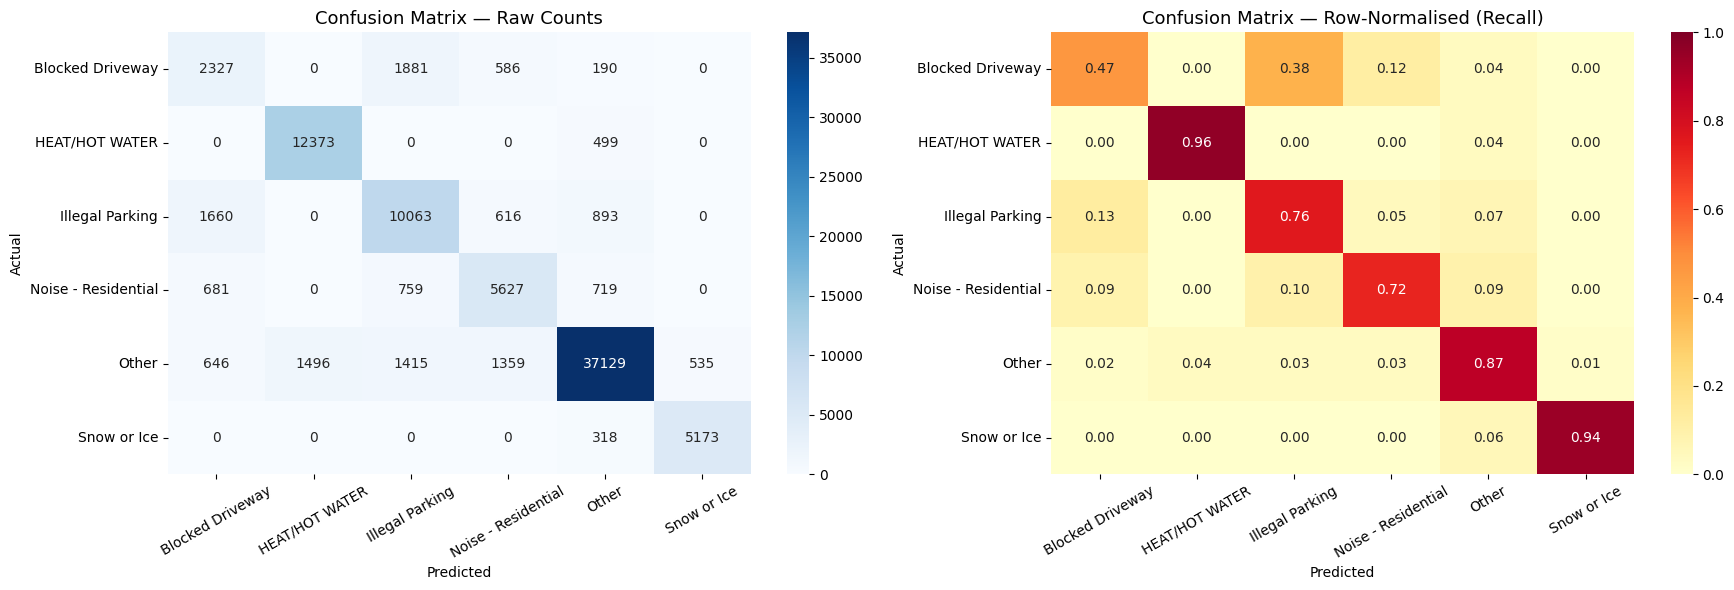

In [25]:
# ── Step 6: Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalized

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)

# Row-normalised (recall per class)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Row-Normalised (Recall)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

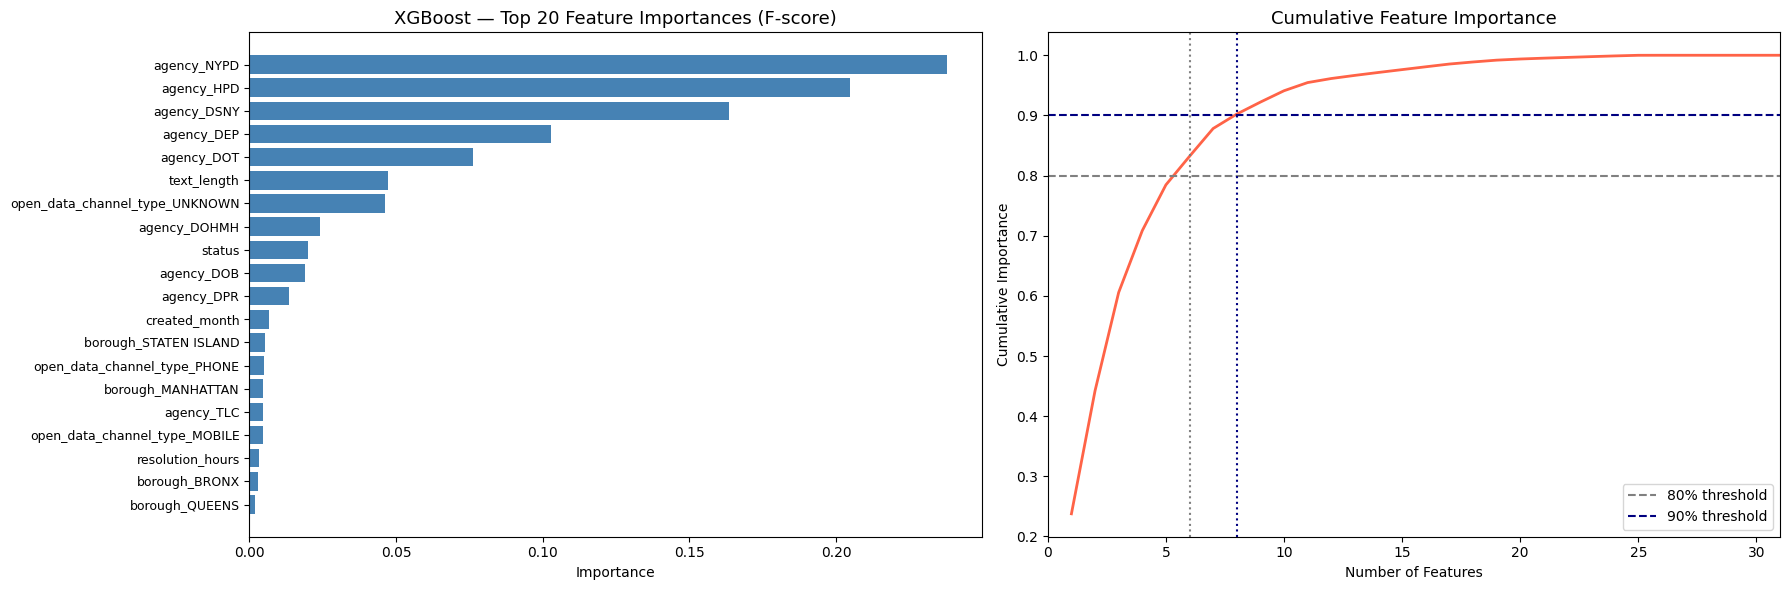


Top 20 most important features:
                       feature  importance
                   agency_NYPD    0.237728
                    agency_HPD    0.204611
                   agency_DSNY    0.163372
                    agency_DEP    0.102776
                    agency_DOT    0.076083
                   text_length    0.047436
open_data_channel_type_UNKNOWN    0.046224
                  agency_DOHMH    0.023981
                        status    0.019899
                    agency_DOB    0.018881
                    agency_DPR    0.013586
                 created_month    0.006760
         borough_STATEN ISLAND    0.005202
  open_data_channel_type_PHONE    0.004883
             borough_MANHATTAN    0.004714
                    agency_TLC    0.004693
 open_data_channel_type_MOBILE    0.004580
              resolution_hours    0.003417
                 borough_BRONX    0.003039
                borough_QUEENS    0.001903

  6 features explain 80% of total importance
  8 features expla

In [26]:
# ── Step 7: Feature Importance ────────────────────────────────────────────────
importances = xgb_clf.feature_importances_
feat_df = (
    pd.DataFrame({'feature': feature_cols, 'importance': importances})
    .sort_values('importance', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20 features
top20 = feat_df.head(20)
axes[0].barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
axes[0].set_title('XGBoost — Top 20 Feature Importances (F-score)', fontsize=13)
axes[0].set_xlabel('Importance')
axes[0].tick_params(axis='y', labelsize=9)

# Cumulative importance curve
cum_imp = feat_df['importance'].cumsum() / feat_df['importance'].sum()
axes[1].plot(range(1, len(cum_imp)+1), cum_imp, color='tomato', linewidth=2)
axes[1].axhline(0.8, color='grey', linestyle='--', label='80% threshold')
axes[1].axhline(0.9, color='navy', linestyle='--', label='90% threshold')
n80 = (cum_imp < 0.8).sum() + 1
n90 = (cum_imp < 0.9).sum() + 1
axes[1].axvline(n80, color='grey', linestyle=':')
axes[1].axvline(n90, color='navy', linestyle=':')
axes[1].set_title('Cumulative Feature Importance', fontsize=13)
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].legend()
axes[1].set_xlim(0, len(cum_imp))

plt.tight_layout()
plt.show()

print(f"\nTop 20 most important features:")
print(feat_df.head(20).to_string(index=False))
print(f"\n  {n80} features explain 80% of total importance")
print(f"  {n90} features explain 90% of total importance")

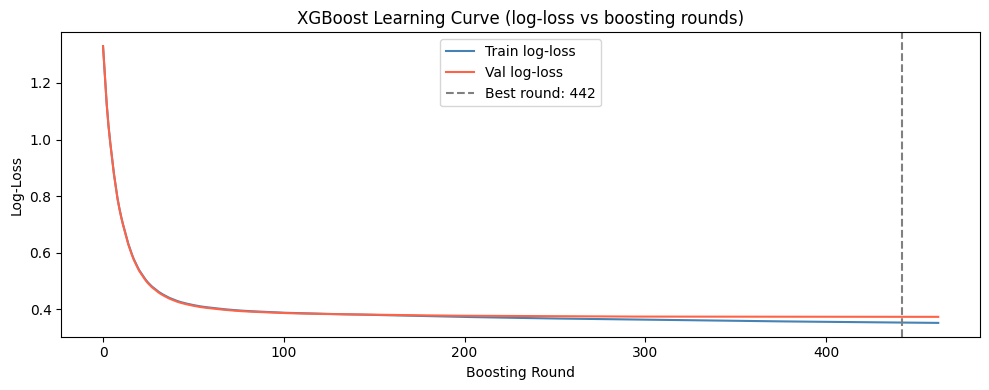

Best iteration  : 442
Best val loss   : 0.3737
Final train loss: 0.3536


In [27]:
# ── Step 9: Learning Curve — Loss over Boosting Rounds ────────────────────────
# Retrain with early stopping to see when the model converges

xgb_es = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    tree_method='hist',
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

evals = xgb_es.evals_result()
train_loss = evals['validation_0']['mlogloss']
val_loss   = evals['validation_1']['mlogloss']
best_round = xgb_es.best_iteration

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, label='Train log-loss', color='steelblue')
ax.plot(val_loss,   label='Val log-loss',   color='tomato')
ax.axvline(best_round, color='grey', linestyle='--',
           label=f'Best round: {best_round}')
ax.set_title('XGBoost Learning Curve (log-loss vs boosting rounds)')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log-Loss')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best iteration  : {best_round}")
print(f"Best val loss   : {val_loss[best_round]:.4f}")
print(f"Final train loss: {train_loss[best_round]:.4f}")

---

## Part 3: Reflection

**Questions to answer after running all cells above:**

1. **What accuracy did XGBoost achieve?** How does this compare to the other models in the comparison chart?

2. **Which features were most important?** Look at the top 20 feature importance chart. Are the top drivers what you expected based on the EDA in Parts 1–2?

3. **Where does the model struggle?** Examine the confusion matrix. Which complaint category has the lowest recall, and why might that be (think about class balance and feature overlap)?

4. **What does the learning curve tell you?** Did the model converge early (suggesting simpler patterns) or late (suggesting complex patterns in the data)?

5. **What would you try next?** For example: adding TF-IDF features from the `descriptor` column, tuning `max_depth` / `learning_rate`, or handling class imbalance with `sample_weight`.

---

*Next steps to improve performance:*
- Add TF-IDF features from the cleaned `descriptor` column (sparse matrix concatenation)
- Try `scale_pos_weight` or SMOTE for the minority classes
- Use `xgb.cv()` or `GridSearchCV` / `Optuna` for hyperparameter search
- Save the trained model with `xgb_clf.save_model('xgb_311.ubj')`

---

## Part 4: Response Time Optimization

**Goal:** Predict how many hours a 311 complaint will take to resolve.

This is an **XGBoost regression** problem:
- **Input (features):** borough, agency, complaint category, submission channel, hour, day, month
- **Output (target):** `resolution_hours` — how long until the complaint is closed

**Why it matters for the city:**
- Spot which complaint types are slowest to resolve
- Identify which boroughs/agencies have the longest delays
- Help dispatchers prioritize complaints that are likely to take a long time
- Set realistic expectations for residents when they file a complaint

In [28]:
# ── Step 1: Prepare regression dataset ───────────────────────────────────────
# Target: resolution_hours (unscaled, original hours from df)
# We use df['resolution_hours'] — computed in EDA cell 5 — because
# df_categorized has a scaled version (StandardScaler was applied).

# Get original unscaled resolution_hours
y_reg_raw = df['resolution_hours'].copy()

# Get features from df_categorized (all structured features, already encoded)
# Include complaint_type as a feature — knowing the type helps predict resolution time
from sklearn.preprocessing import LabelEncoder

df_reg = df_categorized.copy()

# Encode complaint_type as a numeric feature (not the target here)
le_type = LabelEncoder()
df_reg['complaint_type_enc'] = le_type.fit_transform(df_reg['complaint_type'])

# Feature columns: everything except descriptor and original complaint_type string
reg_feature_cols = [c for c in df_reg.columns
                    if c not in ('complaint_type', 'descriptor', 'resolution_hours')]

X_reg = df_reg[reg_feature_cols].copy()
y_reg = y_reg_raw.copy()

# Align index — keep only rows where resolution_hours is valid
valid_mask = (
    y_reg.notna() &          # complaint must be closed (has a resolution time)
    (y_reg >= 0) &           # no negative durations
    (y_reg <= y_reg.quantile(0.98))  # cap extreme outliers at 98th percentile
)

X_reg = X_reg[valid_mask].reset_index(drop=True)
y_reg = y_reg[valid_mask].reset_index(drop=True)

print(f"Rows after filtering      : {len(X_reg):,}  (removed {(~valid_mask).sum():,} rows)")
print(f"Feature columns           : {X_reg.shape[1]}")
print(f"\nTarget (resolution_hours) stats:")
print(y_reg.describe().round(1))
print(f"\nMost complaints resolve within: {y_reg.quantile(0.75):.1f} hours (75th pct)")

Rows after filtering      : 376,898  (removed 57,824 rows)
Feature columns           : 31

Target (resolution_hours) stats:
count    376898.0
mean         37.1
std          66.1
min           0.0
25%           1.0
50%           5.4
75%          46.3
max         428.8
Name: resolution_hours, dtype: float64

Most complaints resolve within: 46.3 hours (75th pct)


In [29]:
# ── Step 2: Train / Test split ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
import numpy as np

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print(f"Training rows : {len(X_reg_train):,}")
print(f"Test rows     : {len(X_reg_test):,}")
print(f"\nTarget distribution in training set:")
print(f"  Mean   : {y_reg_train.mean():.1f} hours  ({y_reg_train.mean()/24:.1f} days)")
print(f"  Median : {y_reg_train.median():.1f} hours  ({y_reg_train.median()/24:.1f} days)")
print(f"  Std    : {y_reg_train.std():.1f} hours")

Training rows : 301,518
Test rows     : 75,380

Target distribution in training set:
  Mean   : 37.1 hours  (1.5 days)
  Median : 5.4 hours  (0.2 days)
  Std    : 66.0 hours


In [30]:
# ── Step 3: Train XGBoost Regressor ───────────────────────────────────────────
import xgboost as xgb

# XGBRegressor predicts a continuous number (hours), not a class label
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',   # minimise mean squared error
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    tree_method='hist',
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost Regressor ...")
xgb_reg.fit(
    X_reg_train, y_reg_train,
    eval_set=[(X_reg_test, y_reg_test)],
    verbose=50
)
print("\nTraining complete!")

Training XGBoost Regressor ...
[0]	validation_0-rmse:64.01934
[50]	validation_0-rmse:47.71607
[100]	validation_0-rmse:46.99558
[150]	validation_0-rmse:46.75003
[200]	validation_0-rmse:46.59959
[250]	validation_0-rmse:46.51836
[299]	validation_0-rmse:46.46255

Training complete!


In [31]:
# ── Step 4: Evaluate — MAE, RMSE, R² ─────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_reg_pred = xgb_reg.predict(X_reg_test)

mae   = mean_absolute_error(y_reg_test, y_reg_pred)
rmse  = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2    = r2_score(y_reg_test, y_reg_pred)
mape  = np.mean(np.abs((y_reg_test - y_reg_pred) / (y_reg_test + 1))) * 100  # +1 avoids /0

print("=" * 55)
print("  XGBoost Regressor — Response Time Results")
print("=" * 55)
print(f"  MAE   (Mean Absolute Error)  : {mae:.1f} hours  ({mae/24:.1f} days)")
print(f"  RMSE  (Root Mean Sq. Error)  : {rmse:.1f} hours  ({rmse/24:.1f} days)")
print(f"  R²    (Variance explained)   : {r2:.4f}  ({r2*100:.1f}%)")
print(f"  MAPE  (Mean Abs % Error)     : {mape:.1f}%")
print("=" * 55)
print()
print("How to read these:")
print(f"  - On average, predictions are off by {mae:.0f} hours ({mae/24:.1f} days)")
print(f"  - The model explains {r2*100:.1f}% of the variation in resolution time")
print(f"  - Baseline (predicting mean every time): MAE = {mean_absolute_error(y_reg_test, [y_reg_train.mean()]*len(y_reg_test)):.1f} hrs")

  XGBoost Regressor — Response Time Results
  MAE   (Mean Absolute Error)  : 23.8 hours  (1.0 days)
  RMSE  (Root Mean Sq. Error)  : 46.5 hours  (1.9 days)
  R²    (Variance explained)   : 0.5124  (51.2%)
  MAPE  (Mean Abs % Error)     : 253.8%

How to read these:
  - On average, predictions are off by 24 hours (1.0 days)
  - The model explains 51.2% of the variation in resolution time
  - Baseline (predicting mean every time): MAE = 44.0 hrs


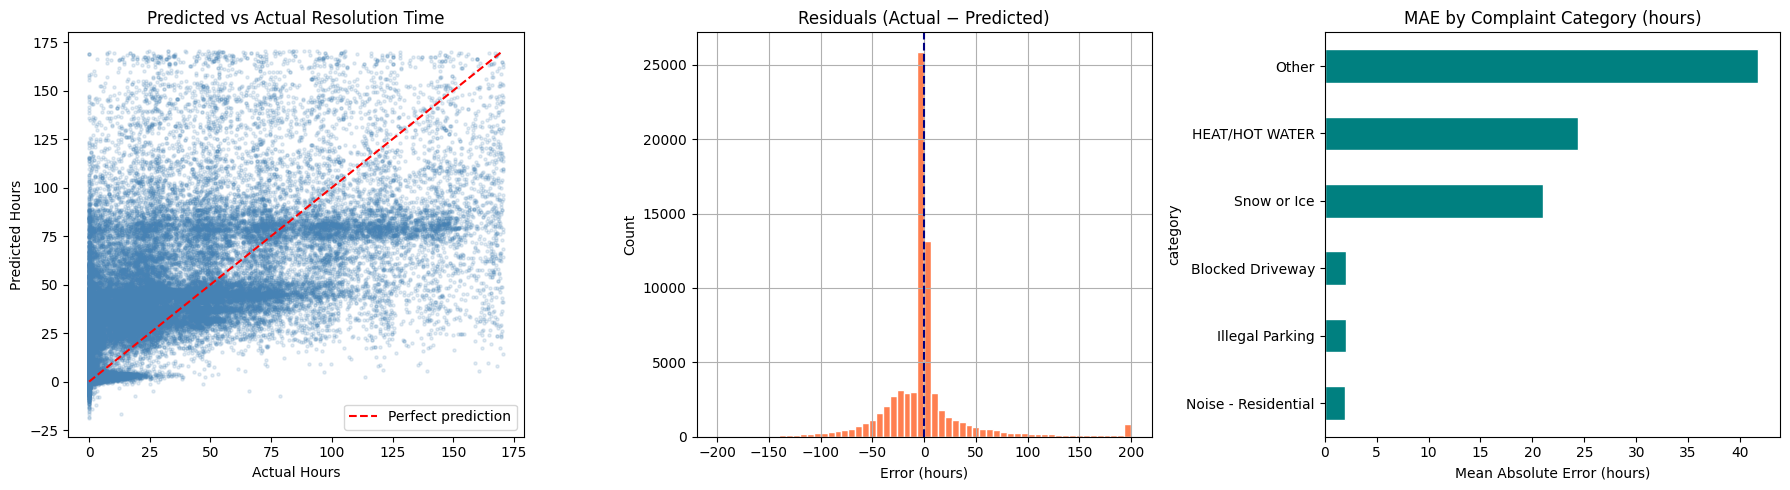


MAE per complaint category:
  Noise - Residential       2.0 hrs  (0.1 days)
  Illegal Parking           2.1 hrs  (0.1 days)
  Blocked Driveway          2.1 hrs  (0.1 days)
  Snow or Ice               21.0 hrs  (0.9 days)
  HEAT/HOT WATER            24.4 hrs  (1.0 days)
  Other                     41.8 hrs  (1.7 days)


In [32]:
# ── Step 5: Visualise Predictions ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_reg_test.values - y_reg_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Actual scatter
cap = np.percentile(y_reg_test, 95)
mask = (y_reg_test <= cap) & (y_reg_pred <= cap)
axes[0].scatter(y_reg_test[mask], y_reg_pred[mask],
                alpha=0.15, s=5, color='steelblue')
axes[0].plot([0, cap], [0, cap], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title('Predicted vs Actual Resolution Time')
axes[0].set_xlabel('Actual Hours')
axes[0].set_ylabel('Predicted Hours')
axes[0].legend()

# 2. Residual distribution
pd.Series(residuals).clip(-200, 200).hist(
    bins=60, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(0, color='navy', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals (Actual − Predicted)')
axes[1].set_xlabel('Error (hours)')
axes[1].set_ylabel('Count')

# 3. Mean Absolute Error per complaint category
test_idx = y_reg_test.index
cat_labels = df_reg.loc[valid_mask].reset_index(drop=True).loc[test_idx, 'complaint_type']
mae_by_cat = (
    pd.DataFrame({'actual': y_reg_test.values,
                  'predicted': y_reg_pred,
                  'category': cat_labels.values})
    .groupby('category')
    .apply(lambda g: mean_absolute_error(g['actual'], g['predicted']))
    .sort_values()
)
mae_by_cat.plot(kind='barh', ax=axes[2], color='teal', edgecolor='white')
axes[2].set_title('MAE by Complaint Category (hours)')
axes[2].set_xlabel('Mean Absolute Error (hours)')

plt.tight_layout()
plt.show()

print(f"\nMAE per complaint category:")
for cat, err in mae_by_cat.items():
    print(f"  {cat:<25} {err:.1f} hrs  ({err/24:.1f} days)")

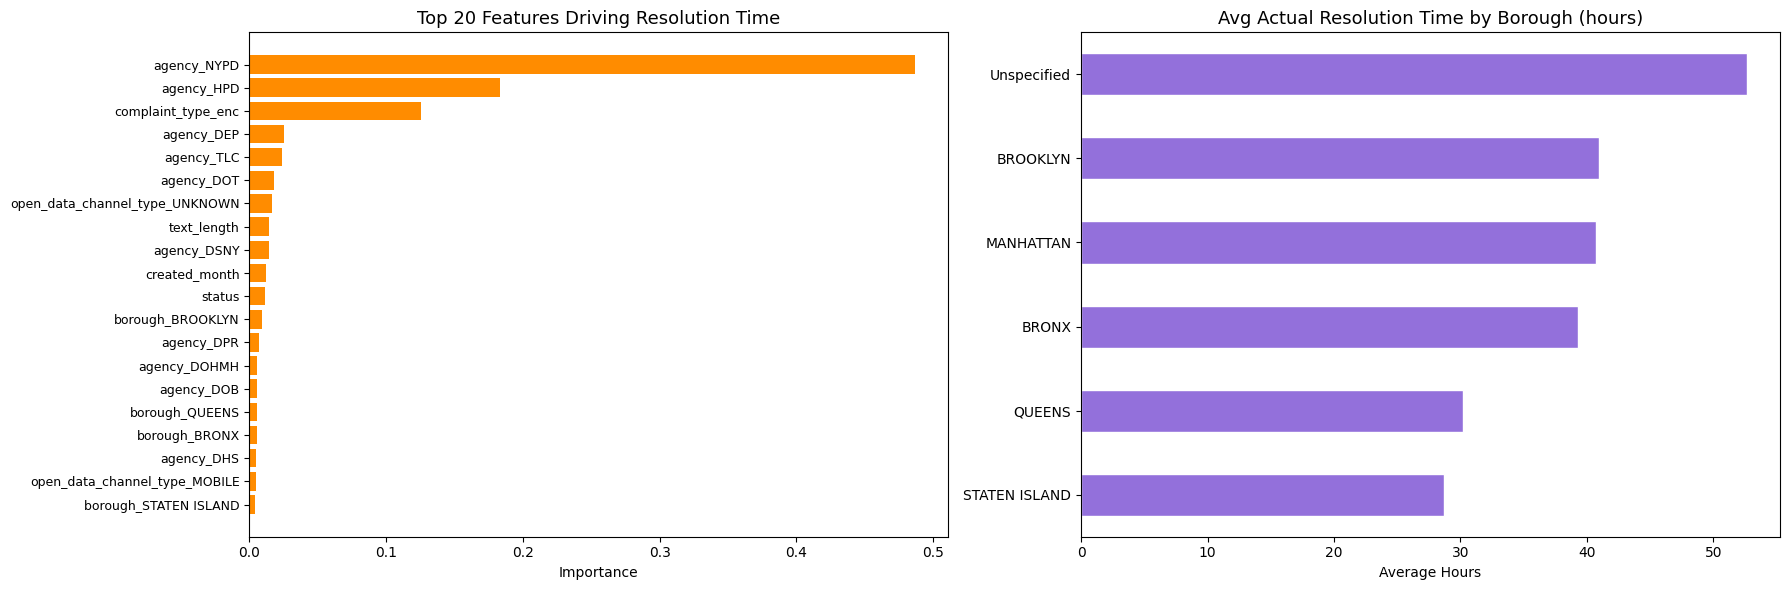

Top 15 features driving resolution time:
                       feature  importance
                   agency_NYPD    0.486682
                    agency_HPD    0.183417
            complaint_type_enc    0.125774
                    agency_DEP    0.025252
                    agency_TLC    0.023560
                    agency_DOT    0.017824
open_data_channel_type_UNKNOWN    0.016718
                   text_length    0.014516
                   agency_DSNY    0.014024
                 created_month    0.012395
                        status    0.011105
              borough_BROOKLYN    0.009069
                    agency_DPR    0.007007
                  agency_DOHMH    0.005344
                    agency_DOB    0.005327


In [33]:
# ── Step 6: Feature Importance — What Drives Resolution Time? ─────────────────
import pandas as pd

imp = xgb_reg.feature_importances_
feat_reg_df = (
    pd.DataFrame({'feature': reg_feature_cols, 'importance': imp})
    .sort_values('importance', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20
top20 = feat_reg_df.head(20)
axes[0].barh(top20['feature'][::-1], top20['importance'][::-1], color='darkorange')
axes[0].set_title('Top 20 Features Driving Resolution Time', fontsize=13)
axes[0].set_xlabel('Importance')
axes[0].tick_params(axis='y', labelsize=9)

# Avg resolution hours per borough
borough_cols = [c for c in df_reg.columns if c.startswith('borough_')]
borough_avg = {}
for col in borough_cols:
    borough_name = col.replace('borough_', '')
    mask2 = valid_mask & (df_categorized[col] == 1)
    if mask2.sum() > 0:
        borough_avg[borough_name] = df['resolution_hours'][mask2].mean()

pd.Series(borough_avg).sort_values().plot(
    kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Avg Actual Resolution Time by Borough (hours)', fontsize=13)
axes[1].set_xlabel('Average Hours')

plt.tight_layout()
plt.show()

print("Top 15 features driving resolution time:")
print(feat_reg_df.head(15).to_string(index=False))

In [34]:
# ── Step 7: Practical Demo — Predict Resolution Time for a New Complaint ──────
# Simulates what a dispatcher would see when a new complaint comes in

def predict_resolution_time(complaint_type, agency, borough, channel, hour, month):
    """
    Predict how long (hours) it will take to resolve a complaint.
    Uses the trained XGBoost regressor.
    """
    # Start from a zero row matching the feature schema
    row = pd.DataFrame([{col: 0 for col in reg_feature_cols}])

    # Set time features
    row['created_hour']      = hour
    row['created_dayofweek'] = 0        # Monday as default
    row['created_month']     = month
    row['status']            = 3        # In Progress

    # Set one-hot flags
    borough_col  = f'borough_{borough.upper()}'
    channel_col  = f'open_data_channel_type_{channel.upper()}'
    agency_col   = f'agency_{agency.upper()}'
    if borough_col  in row.columns: row[borough_col]  = 1
    if channel_col  in row.columns: row[channel_col]  = 1
    if agency_col   in row.columns: row[agency_col]   = 1

    # Encode complaint type
    if complaint_type in le_type.classes_:
        row['complaint_type_enc'] = le_type.transform([complaint_type])[0]

    hours = float(xgb_reg.predict(row)[0])
    days  = hours / 24
    return hours, days


# Run 5 realistic scenarios
scenarios = [
    ("HEAT/HOT WATER",    "HPD",   "BRONX",     "ONLINE", 22, 1),
    ("Illegal Parking",   "NYPD",  "BROOKLYN",  "MOBILE",  9, 3),
    ("Noise - Residential","NYPD", "MANHATTAN", "PHONE",  23, 6),
    ("Snow or Ice",       "DSNY",  "QUEENS",    "ONLINE",  7, 2),
    ("Blocked Driveway",  "NYPD",  "BROOKLYN",  "MOBILE",  8, 4),
]

print(f"{'Complaint Type':<25} {'Agency':<6} {'Borough':<12} {'Hour':>4} {'Month':>5}  →  Predicted Time")
print("-" * 75)
for comp, agency, borough, channel, hour, month in scenarios:
    hrs, days = predict_resolution_time(comp, agency, borough, channel, hour, month)
    print(f"{comp:<25} {agency:<6} {borough:<12} {hour:>4}   {month:>3}   →  "
          f"{hrs:>6.1f} hrs  ({days:.1f} days)")

Complaint Type            Agency Borough      Hour Month  →  Predicted Time
---------------------------------------------------------------------------
HEAT/HOT WATER            HPD    BRONX          22     1   →    41.7 hrs  (1.7 days)
Illegal Parking           NYPD   BROOKLYN        9     3   →     4.3 hrs  (0.2 days)
Noise - Residential       NYPD   MANHATTAN      23     6   →    12.4 hrs  (0.5 days)
Snow or Ice               DSNY   QUEENS          7     2   →    11.9 hrs  (0.5 days)
Blocked Driveway          NYPD   BROOKLYN        8     4   →     4.5 hrs  (0.2 days)


---

## Part 4: Reflection

**Questions to answer after running all cells above:**

1. **What was the MAE?** In plain English — on average, how many hours off are the predictions? Is that acceptable for city operations?

2. **Which complaint category was hardest to predict?** Look at "MAE by Complaint Category." Why might some types be harder than others?

3. **What were the top 3 features?** Look at the feature importance chart. Are they what you expected — or surprising?

4. **Compare MAE to the baseline.** The baseline is just predicting the average every time. How much better is XGBoost than that baseline?

5. **Look at the practical demo.** Does the HEAT/HOT WATER complaint at 10pm in January (winter, late night) get a longer predicted time than Illegal Parking in the morning? Does that make sense?

---

### What you built across Parts 3 & 4

| Part | Problem type | XGBoost type | What it answers |
|------|-------------|--------------|-----------------|
| Part 3 | Classification | `XGBClassifier` | *What category is this complaint?* |
| Part 4 | Regression | `XGBRegressor` | *How long will it take to resolve?* |

These two models together give the city a complete picture: **route the complaint correctly AND estimate when it will be resolved.**